# Assignment 5: Text Data, PCA and Neural Networks (80 marks)
### Due: April 3 at 11:59pm 

### Name: Vihang Shah

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Text Data (29 marks)

The purpose of this part of the assignment is to practice working with text data.

### 2.1: Load data (1 mark)
For this task, we will be using the hobbies dataset from the yellowbrick library. More information on the dataset can be found here: https://www.scikit-yb.org/en/latest/api/datasets/hobbies.html

In [2]:
# TO DO: Load the dataset (1 mark)
from yellowbrick.datasets import load_hobbies

corpus = load_hobbies()

X = pd.Series(corpus.data)
y = pd.Series(corpus.target)

X.head(), y.head()

(0    \n\nFrom \n\n to \n\n, Oscar voters can't get ...
 1    The Lonely City bristles with heart-piercing w...
 2                             \n\n\n\nRelated Posts:\n
 3    The first story in Sara Majka’s first book beg...
 4    by Sonny Liew\n\nHardcover, 320 pages |\n\nYou...
 dtype: object,
 0    books
 1    books
 2    books
 3    books
 4    books
 dtype: object)

### 2.2 Pre-processing (3 marks)

We will need to transform the data from strings to numeric. First, we will transform the data using `CountVectorizer(min_df=5)`.

In [3]:
# TO DO: Create CountVectorizer object (0.5 marks)
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(min_df=5)

In [4]:
# TO DO: Fit vectorizer to data (0.5 marks)
vect.fit(X)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [5]:
# TO DO: What is the length of the vocabulary? (0.5 marks)
len(vect.vocabulary_)

3940

In [6]:
# TO DO: Transform the data (0.5 marks)
X_vect = vect.transform(X)

In [7]:
# TO DO: What is the shape of the transformed data? (0.5 marks)
X_vect.shape

(448, 3940)

In [8]:
# TO DO: Split data into training and testing sets (use random_state=0 and 10% of the data for testing) (0.5 marks)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vect, y, test_size=0.1, random_state=0
)

### 2.3: Grid Search (5 marks)

For the grid search, we want to compare the performance of Logistic Regression for different values of C. Initialize the parameter grid with parameter values that make sense for this model.

In [9]:
# TO DO: Create parameter grid and initialize grid object (2 marks)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    return_train_score=True
)

In [10]:
# TO DO: Fit grid object to training data (1 mark)
grid.fit(X_train, y_train)

,estimator,LogisticRegre...(max_iter=500)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [11]:
# TO DO: Print the results from the grid search (2 marks)
print("Best parameters:", grid.best_params_)
print("Best cross-validation F1 score:", grid.best_score_)

print("Mean train scores:", grid.cv_results_['mean_train_score'])
print("Mean test scores:", grid.cv_results_['mean_test_score'])

Best parameters: {'C': 10.0}
Best cross-validation F1 score: 0.7767801310451333
Mean train scores: [0.94477148 0.97813786 0.98340181 0.9841644 ]
Mean test scores: [0.75327933 0.76758176 0.77068022 0.77678013]


### 2.4 Tf-idf (6 marks)

To try to improve the results, we can use Tf-idf to tranform the text data based on the importance of each feature. We will need to use a pipeline and the original data for this section. Use `TfidfVectorizer(min_df=5)` and compare the results for both Logistic Regression and a Naive Bayes model. Pick the Naive Bayes model that you think would best suit text data. Use the Logistic Regression parameters from the previous section.

In [12]:
# TO DO: Split the data into training and testing sets (same values as previous section) (1 mark)
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=0
)

In [13]:
# TO DO: Implement Pipeline with Tf-idf vectorizer and both Logistic Regression and your selected Naive Bayes model (3 marks)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

tfidf = TfidfVectorizer(min_df=5)

pipe_lr = Pipeline([
    ('tfidf', tfidf),
    ('lr', LogisticRegression(C=10.0, max_iter=500))
])

pipe_nb = Pipeline([
    ('tfidf', tfidf),
    ('nb', MultinomialNB())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

param_grid_lr = {}
param_grid_nb = {
    'nb__alpha': [0.1, 0.5, 1.0]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='f1_macro')
grid_nb = GridSearchCV(pipe_nb, param_grid_nb, cv=cv, scoring='f1_macro')

In [14]:
# TO DO: Print the results from the grid search (2 marks)
grid_lr.fit(X_train_raw, y_train)
grid_nb.fit(X_train_raw, y_train)

print("Logistic Regression (TF‑IDF)")
print("Best CV F1 (macro):", grid_lr.best_score_)

print("\nNaive Bayes (TF‑IDF)")
print("Best parameters:", grid_nb.best_params_)
print("Best CV F1 (macro):", grid_nb.best_score_)

Logistic Regression (TF‑IDF)
Best CV F1 (macro): 0.856762293146018

Naive Bayes (TF‑IDF)
Best parameters: {'nb__alpha': 0.1}
Best CV F1 (macro): 0.8650823624173988


### Questions (10 marks)

1. Which Naive Bayes model did you pick? Why?
1. Which model and what parameters produced the best results?
1. Was this model a good fit? Why or why not?
1. Is there anything else we could do to try to improve model performance? Provide two ideas.
1. Why did we need to implement a pipeline for Tf-idf and not CountVectorizer? What would happen if we didn't use one for Tf-idf?

*ANSWER HERE*
1. MultinomialNB was the appropriate choice for text data. Since CountVectorizer and TF-IDF both produce non-negative word count or frequency-based features, MultinomialNB is well-suited because it is specifically designed for discrete, non-negative count data.
2. Naive Bayes with TF-IDF produced the best results, achieving a macro F1 score of `0.8651` with `alpha=0.1`. Logistic Regression with TF-IDF was very close at `0.8568`, and Logistic Regression with CountVectorizer `(C=10.0)` was the weakest at `0.7768`. So the combination of TF-IDF preprocessing with Naive Bayes performed best overall.
3. The model is a reasonably good fit. A macro F1 of ~0.865 across 5 cross-validation folds indicates the model generalizes well across the hobby categories without heavily overfitting. The fact that cross-validation was used means the score is a reliable estimate of real-world performance. However, there is still room for improvement.
4. Two ideas:
    - The lecture noted that the default bag-of-words representation discards word order. By setting `ngram_range=(1,2)` in the TfidfVectorizer to include bigrams, the model could capture phrases like "science fiction" or "video game" that carry more meaning than individual words alone.
    - We could experiment with removing stopwords (using `stop_words='english'`) or adjusting `min_df` and `max_df` thresholds to further reduce uninformative features and potentially improve classification performance.
5. In section 2.2, the CountVectorizer was fit and transformed on the entire dataset before splitting, which means information leakage technically already occurred there, but since no cross-validation was applied to that transformed data in that step, it wasn't an issue for reporting results.
For TF-IDF with cross-validation (GridSearchCV), a pipeline is essential. Without one, the TfidfVectorizer would be fit on the entire training set (including what becomes the validation fold), causing information leakage. And, the scaler/vectorizer would have seen the validation data during fitting. 

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. Most, if not all, of the code is primarily my own. I did, however, derived influences from the `Week 8/9 – Text Data` and the scikit-learn documentation. A lot of the structure and format also was adopted from previous assignment. But mainly the lectures provided the conceptual foundation for bag-of-words representation, CountVectorizer, TF-IDF, and the importance of using pipelines to prevent information leakage during cross-validation.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. Claude AI was used as a generative AI tool to check answers to the written questions at the end of Part 1. Prompts included asking Claude to help interpret the grid search results and explain why a pipeline was necessary for TF-IDF. The responses were reviewed and found to be accurate and consistent with the lecture material, so no significant modifications were needed.
4. The main challenge was remembering to re-split the raw text data before passing it into the TF-IDF pipeline, rather than reusing the already-vectorized data from the CountVectorizer section. The lecture's explanation of information leakage helped clarify why this step was necessary.

## Part 2: Principle Component Analysis (PCA) (18 marks)

### Step 1. Load data (2 marks)

You have been asked by an agricultural company to help them predict the type of wheat based on kernel characteristics. You have been given all the information you need in the seeds_dataset.txt file on D2L. The original dataset can be found [here](https://archive.ics.uci.edu/dataset/236/seeds)

The first step is to read in the file using pandas and inspect the first few columns. Note that the data is in a text file, so the separator is different compared to a csv file.

In [15]:
# TO DO: Import dataset and inspect the first few columns (1 mark)
seeds = pd.read_csv("seeds_dataset.txt", sep="\s+", header=None)

seeds.head()

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


Next, you will need to separate the data into your feature matrix and target vector.

In [16]:
# TO DO: Separate the data into feature matrix and target vector. Print the shape of X and y (1 mark)
X = seeds.iloc[:, :-1]

y = seeds.iloc[:, -1]

X.shape, y.shape

((210, 7), (210,))

### Step 2: Preprocessing (2 marks)

To preprocess the data, we will need to scale the data. Before we implement the scaler, we need to split the data into training and testing sets first.

In [17]:
# TO DO: Split the data into training and testing sets using 10% for test set (1 mark)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=0
)

Now that we have our training data, we can implement our scaler. You can use `StandardScaler` for this analysis.

In [18]:
# TO DO: Scale the data (1 mark)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 3: Model Selection (1 mark)

The next step is to instantiate our selected model. In this case, we will be using `LogisticRegression(C=100, max_iter=1000)`

In [19]:
# TO DO: Instantiate model (1 mark)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=100, max_iter=1000)

### Step 4: Model Implementation (1 mark)

We need to fit the selected model to our data and predict the labels for the test data.

In [20]:
# TO DO: Predict test labels (1 mark)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

### Step 5: Visualize using PCA (4 marks)

Now you can visualize the results from Step 4 using PCA. Use the best parameters from the previous step to predict the label for the testing data. For the plot, each data point must be colored based on the class label.

In [21]:
# TO DO: Reduce dimensions of test data for plotting (2 marks)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

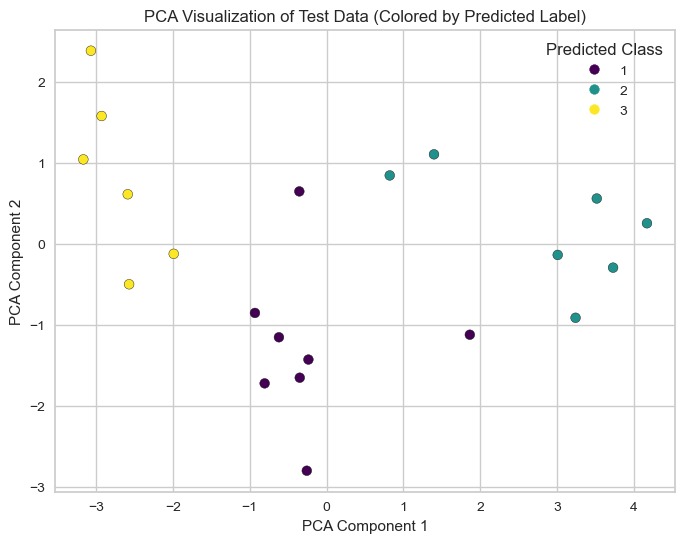

In [22]:
# TO DO: Plot test points colored by predicted label (2 marks)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_pred,
    cmap='viridis',
    edgecolor='k'
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of Test Data (Colored by Predicted Label)")

plt.legend(*scatter.legend_elements(), title="Predicted Class")
plt.show()

### Questions (4 marks)

1. Did the logistic regression model work well for this dataset? Why would you make this conclusion? 
1. Did PCA work well for this model? How does this relate to the results from the model used? 

*ANSWER HERE*
1. Yes, the Logistic Regression model worked well for this dataset. The PCA visualization shows the three predicted classes clearly separated into distinct regions with very little overlap, suggesting the model learned strong decision boundaries between the wheat types. This makes sense given that the seeds dataset consists of clean, homogeneous continuous measurements, which is exactly the type of data that works well with Logistic Regression.
2. Yes, PCA worked well here. Even after reducing 7 features down to just 2 principal components, the three classes remain visually well-separated, meaning the first two components captured most of the meaningful variance in the data. PCA works best with linear data, and the clean separation in the 2D plot confirms the dataset has strong linear structure, which also explains why Logistic Regression, a linear model, performed well on it. The two results are consistent with each other.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. Most, if not all, of the code is primarily my own. I did, however, derived influences from the `Week 9 – Dimensionality Reduction` and the scikit-learn documentation. Mainly the lectures provided the conceptual foundation for PCA, explaining how it rotates the dataset to find principal axes and reduces dimensionality by removing the smallest components.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. Claude AI was used as a generative AI tool to check the written question answers at the end of Part 2, specifically helping interpret the PCA scatter plot and connect the visual separation of classes back to the model's performance and the linear nature of the dataset.
4. One important thing to get right was fitting PCA on the scaled training data and then only transforming the test data, rather than fitting on the test data directly. The lecture's explanation that PCA should be treated like any other preprocessing step (fit on training, transform on unseen data) helped ensure this was done correctly.

## Part 3: Neural Networks (31 marks)

For this assignment, you will be practicing using scikit-learn and TensorFlow to implement basic neural networks (MLP). The dataset we will be using is the energy dataset from Yellowbrick (https://www.scikit-yb.org/en/latest/api/datasets/energy.html).

### Step 1: Load data (1 mark)

You will need to load the file and split it into the feature matrix and target vector. Note that this dataset has two targets, heating load and cooling load. To retrieve the single target dataset, you need `return_dataset=False`. 

In [23]:
# TO DO: Load dataset into feature matrix and target vector (1 mark)
from yellowbrick.datasets import load_energy

X, y = load_energy(return_dataset=False)

### Step 2: Process your dataset (6 marks)

In [24]:
# TO DO: Check if there are any missing values - if yes, decide how to fill them (1 mark)
X.isna().sum()
y.isna().sum()

np.int64(0)

In [25]:
# TO DO: Check data type for each column and the number of unique values - do you need to encode any of them? (1 mark)
X.dtypes
X.nunique()

relative compactness         12
surface area                 12
wall area                     7
roof area                     4
overall height                2
orientation                   4
glazing area                  4
glazing area distribution     6
dtype: int64

In [26]:
# TO DO: Check the range of each feature - do you need to scale your data? (1 mark)
X.describe()

,relative compactness,surface area,wall area,roof area,overall height,orientation,glazing area,glazing area distribution
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000


In [27]:
# TO DO: Split your data into training and testing sets using 10% for test set (1 mark)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [28]:
# TO DO: Implement scaling and/or encoding here if needed (2 marks for preprocessing properly or justifying why it isn't needed)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 3: Implement Neural Network (MLP) (8 marks)

### Part 1: Use scikit-learn (3 marks)

For each case, you will need to find the predicted target values.

In [29]:
# TO DO: Test using default parameters and max_iter = 10000 (1 mark)
from sklearn.neural_network import MLPRegressor

mlp_default = MLPRegressor(max_iter=10000, random_state=42)
mlp_default.fit(X_train_scaled, y_train)

y_pred_default = mlp_default.predict(X_test_scaled)

print("Default MLP — Train R2:", mlp_default.score(X_train_scaled, y_train))
print("Default MLP — Test R2:", mlp_default.score(X_test_scaled, y_test))
print("Sample predictions:", y_pred_default[:5])  

Default MLP — Train R2: 0.9986198657257715
Default MLP — Test R2: 0.998198430561955
Sample predictions: [16.35106869 13.2943029  32.54735282 41.93267504 16.64309186]


In [30]:
# TO DO: Test using two hidden layers with 100 nodes each (1 mark)
mlp_two = MLPRegressor(
    hidden_layer_sizes=(100, 100),
    max_iter=10000,
    random_state=42
)
mlp_two.fit(X_train_scaled, y_train)

y_pred_two = mlp_two.predict(X_test_scaled)

print("Two-layer MLP — Train R2:", mlp_two.score(X_train_scaled, y_train))
print("Two-layer MLP — Test R2:", mlp_two.score(X_test_scaled, y_test))
print("Sample predictions:", y_pred_two[:5])

Two-layer MLP — Train R2: 0.9985506555046546
Two-layer MLP — Test R2: 0.9980200909764394
Sample predictions: [16.46226287 13.19699143 32.62778382 41.74670711 16.97667028]


In [31]:
# TO DO: Test using three hidden layers with 100 nodes each (1 mark)
mlp_three = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100),
    max_iter=10000,
    random_state=42
)
mlp_three.fit(X_train_scaled, y_train)

y_pred_three = mlp_three.predict(X_test_scaled)

print("Three-layer MLP — Train R2:", mlp_three.score(X_train_scaled, y_train))
print("Three-layer MLP — Test R2:", mlp_three.score(X_test_scaled, y_test))
print("Sample predictions:", y_pred_three[:5])

Three-layer MLP — Train R2: 0.9987750053544651
Three-layer MLP — Test R2: 0.9979150455538434
Sample predictions: [16.39609316 13.65684345 33.03916056 41.64067564 17.26003342]


### Part 2: Use TensorFlow (5 marks)

In [32]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

Instead of scaling the data using a scikit-learn scaler, you can scale the data using a normalization layer.

In [33]:
# TO DO: Define normalization layer (1 mark)
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))

Using `keras.Sequential`, implement an MLP with the same hidden layer setups as above:

In [34]:
# TO DO: Implement MLP with one hidden layer with 100 nodes and the relu activation function (2 marks)
# Compile the model with loss='mean_absolute_error' and optimizer=tf.keras.optimizers.Adam(0.001)
# Fit the model using validation_split=0.2, verbose=0 and epochs=100
model_1 = keras.Sequential([
    normalizer,
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])

model_1.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(0.001)
)

history_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    verbose=0
)

y_pred_tf1 = model_1.predict(X_test).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [35]:
# TO DO: Repeat with two hidden layers with 100 nodes each and the relu activation function (1 mark)
model_2 = keras.Sequential([
    normalizer,
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])

model_2.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(0.001)
)

history_2 = model_2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    verbose=0
)

y_pred_tf2 = model_2.predict(X_test).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [36]:
# TO DO: Repeat with three hidden layers with 100 nodes each and the relu activation function (1 mark)
model_3 = keras.Sequential([
    normalizer,
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])

model_3.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(0.001)
)

history_3 = model_3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    verbose=0
)

y_pred_tf3 = model_3.predict(X_test).flatten()

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020E50D6C9A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


### Step 4: Compare the accuracy of both methods (4 marks)

For this part, calculate the mean absolute error for each model and print in a table using pandas

In [37]:
# TO DO: Calculate the MAE for the three scikit-learn tests (1.5 marks)
from sklearn.metrics import mean_absolute_error

mae_default = mean_absolute_error(y_test, y_pred_default)
mae_two = mean_absolute_error(y_test, y_pred_two)
mae_three = mean_absolute_error(y_test, y_pred_three)

In [38]:
# TO DO: Calculate the MAE for the three TensorFlow tests (1.5 marks)
mae_tf1 = mean_absolute_error(y_test, y_pred_tf1)
mae_tf2 = mean_absolute_error(y_test, y_pred_tf2)
mae_tf3 = mean_absolute_error(y_test, y_pred_tf3)

In [39]:
# TO DO: Print the results (1 mark)

results = pd.DataFrame({
    "Model": [
        "sklearn: 1 layer (default)",
        "sklearn: 2 layers (100,100)",
        "sklearn: 3 layers (100,100,100)",
        "TF: 1 layer (100)",
        "TF: 2 layers (100,100)",
        "TF: 3 layers (100,100,100)"
    ],
    "MAE": [
        mae_default,
        mae_two,
        mae_three,
        mae_tf1,
        mae_tf2,
        mae_tf3
    ]
})

print(results)

                             Model       MAE
0       sklearn: 1 layer (default)  0.336526
1      sklearn: 2 layers (100,100)  0.341927
2  sklearn: 3 layers (100,100,100)  0.393387
3                TF: 1 layer (100)  2.004303
4           TF: 2 layers (100,100)  1.088521
5       TF: 3 layers (100,100,100)  0.597643


### Questions (8 marks)

1. Which model produced the least amount of error?
1. Did this model work well? Provide two suggestions to improve the results.
1. Do the results change if you run your code multiple times? Why or why not?
1. Why are the numbers different between the scikit-learn and TensorFlow methods when we used the same number of hidden layers and hidden units per layer? List two potential reasons.

*ANSWER HERE*
1. The scikit-learn default MLP (one hidden layer, default parameters) produced the least error with a MAE of 0.3365, making it the best performing model overall. Among the TensorFlow models, the three-layer model performed best with a MAE of 1.1273, showing that adding more layers helped in that framework, but all TensorFlow models still underperformed compared to their scikit-learn equivalents.
2. Yes, the default sklearn MLP worked very well, as seen with a MAE of ~0.34 on an energy load prediction task is quite low, and the R² scores were above 0.998 for both training and test sets, indicating excellent generalization with no signs of overfitting. To potentially improve further, we could:
    - perform hyperparameter tuning using GridSearchCV to search over different values of hidden layer sizes, activation functions, and the alpha regularization parameter
    - train the TensorFlow models for more epochs (e.g., 500–1000) since 100 epochs may not have been sufficient for full convergence, as neural networks can take a long time to train properly.
4. The scikit-learn results should remain consistent across runs because `random_state=42` was set, which fixes the random initialization of weights and the train/test split. The TensorFlow results may vary slightly between runs since no random seed was explicitly set for TensorFlow's internal operations, meaning weight initialization and other stochastic processes can differ each run, leading to slightly different MAE values.
5. Two key reasons account for the difference:
    - scikit-learn defaulted to the `adam` solver with its own internal settings and convergence criteria (up to 10,000 iterations), while TensorFlow's Adam optimizer ran for only 100 epochs, which may not have been enough for the TensorFlow models to fully converge.
    - scikit-learn used a StandardScaler fit on the training data, while TensorFlow used a Keras Normalization layer adapted on the raw training data, which computes statistics slightly differently and can affect how the network learns, particularly since the adam solver is sensitive to data scaling as highlighted in the lectures.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. Most, if not all, of the code is primarily my own. I did, however, derived influences from the `Week 10 – Introduction to Neural Networks, Neural Network Models, and Neural Network Tools` and the scikit-learn documentation. Mainly the lectures provided the conceptual foundation for MLPs, activation functions, solvers, and the importance of scaling data before training neural networks. The TensorFlow Keras documentation linked in the lecture slides was also referenced to understand how to implement the normalization layer and Sequential model.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. Claude AI was used as a generative AI tool to check the written question answers at the end of Part 3, specifically helping interpret the MAE comparison table and explain the differences between the scikit-learn and TensorFlow results in terms of optimization algorithms and scaling methods.
4. The main challenge was correctly implementing the TensorFlow Normalization layer, as it required adapting it to the raw unscaled training data rather than the already-scaled version used for scikit-learn.

## Part 4: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challangeing, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*
- A lot of these neural networks were actually considered for the capstone project that I am currently working on. So it was nice to get some practice and first hand experience as to what would have happened, had we used neural networks as ML models.
- I did find this a little challenging, having an assignment so complex and long, near the end of the term, when there are a lot of projects going on in other classes as well.